# Explicando o Treino


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import math

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset


#CSV_PATH = Path("report-file-1.csv")
CSV_PATH = Path("interpolated_N20_data.csv")
OUTPUT_DIR = Path("artifacts_time")
WINDOW_SIZE = 20
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 0.001

In [2]:
def load_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        csv_path,
        sep=r"\s+",
        skiprows=3,
        header=None,
        engine="python",
    )

    df.columns = [
        "TimeStep",
        "flow_time",
        "delta_time",
        "iters_per_timestep",
        "mon_x",
        "mon_sacarose",
        "mon_glicose",
        "mon_etanol",
    ]

    df = df.replace({"\"": "", r"\(": "", r"\)": ""}, regex=True)
    df = df[["flow_time", "mon_sacarose", "mon_glicose", "mon_etanol"]]
    df = df.astype(float)
    df = df.sort_values("flow_time").reset_index(drop=True)
    return df

In [3]:
def create_samples(state_scaled, flow_scaled, window_size):
    X_hist, future_t, y = [], [], []

    for i in range(len(state_scaled) - window_size):
        target_idx = i + window_size
        history_states = state_scaled[i:target_idx]
        history_flow = flow_scaled[i:target_idx]

        history_features = np.concatenate(
            [history_states, history_flow],
            axis=1,
        )

        X_hist.append(history_features)
        future_t.append(flow_scaled[target_idx])
        y.append(state_scaled[target_idx])

    return np.array(X_hist), np.array(future_t), np.array(y)

In [4]:
class TemporalForecastDataset(Dataset):
    def __init__(self, X_hist, future_t, y):
        self.X_hist = torch.FloatTensor(X_hist)
        self.future_t = torch.FloatTensor(future_t)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X_hist)

    def __getitem__(self, idx):
        return self.X_hist[idx], self.future_t[idx], self.y[idx]

In [5]:
class TimeConditionedLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2, dropout=0.1, output_size=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.time_encoder = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size + 16, 64),
            nn.ReLU(),
            nn.Linear(64, output_size),
        )

    def forward(self, x_hist, future_t):
        _, (hn, _) = self.lstm(x_hist)
        context = hn[-1]
        time_context = self.time_encoder(future_t)
        combined = torch.cat([context, time_context], dim=1)
        return self.head(combined)

In [6]:
def inverse_state(state_scaler, values):
    return state_scaler.inverse_transform(values)

In [7]:
df = load_data(CSV_PATH)

In [8]:
state_values = df[["mon_sacarose", "mon_glicose", "mon_etanol"]].values
flow_values = df[["flow_time"]].values

In [9]:
state_scaler = MinMaxScaler()
flow_scaler = MinMaxScaler()

In [10]:
state_scaled = state_scaler.fit_transform(state_values)
flow_scaled = flow_scaler.fit_transform(flow_values)

In [11]:
X_hist, future_t, y = create_samples(state_scaled, flow_scaled, WINDOW_SIZE)

In [12]:
split_idx = int(0.8 * len(X_hist))
print(f"Total samples: {len(X_hist)}, Train samples: {split_idx}, Test samples: {len(X_hist) - split_idx}")
X_train, X_test = X_hist[:split_idx], X_hist[split_idx:]
t_train, t_test = future_t[:split_idx], future_t[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

Total samples: 21254, Train samples: 17003, Test samples: 4251


In [13]:
split_idx_val = int(0.8 * len(X_train))
print(f"Train samples: {len(X_train)}, Train split: {split_idx_val}, Val samples: {len(X_train) - split_idx_val}")
X_train, X_val = X_train[:split_idx_val], X_train[split_idx_val:]
t_train, t_val = t_train[:split_idx_val], t_train[split_idx_val:]
y_train, y_val = y_train[:split_idx_val], y_train[split_idx_val:]

Train samples: 17003, Train split: 13602, Val samples: 3401


In [14]:
train_dataset = TemporalForecastDataset(X_train, t_train, y_train)
val_dataset = TemporalForecastDataset(X_val, t_val, y_val)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
model = TimeConditionedLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

In [17]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TimeConditionedLSTM(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.1)
  (time_encoder): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [18]:
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, t_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        t_batch = t_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch, t_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, t_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(X_batch, t_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

Epoch [1/100], Train Loss: 0.010684, Val Loss: 0.006948
Epoch [2/100], Train Loss: 0.003044, Val Loss: 0.007119
Epoch [3/100], Train Loss: 0.003754, Val Loss: 0.005846
Epoch [4/100], Train Loss: 0.003124, Val Loss: 0.002541
Epoch [5/100], Train Loss: 0.000777, Val Loss: 0.001625
Epoch [6/100], Train Loss: 0.000366, Val Loss: 0.001868
Epoch [7/100], Train Loss: 0.000103, Val Loss: 0.001970
Epoch [8/100], Train Loss: 0.000087, Val Loss: 0.002182
Epoch [9/100], Train Loss: 0.000038, Val Loss: 0.002116
Epoch [10/100], Train Loss: 0.000148, Val Loss: 0.002137
Epoch [11/100], Train Loss: 0.000081, Val Loss: 0.002206
Epoch [12/100], Train Loss: 0.000064, Val Loss: 0.002569
Epoch [13/100], Train Loss: 0.000041, Val Loss: 0.002467
Epoch [14/100], Train Loss: 0.000060, Val Loss: 0.002368
Epoch [15/100], Train Loss: 0.000056, Val Loss: 0.002313
Epoch [16/100], Train Loss: 0.000056, Val Loss: 0.002068
Epoch [17/100], Train Loss: 0.000092, Val Loss: 0.002204
Epoch [18/100], Train Loss: 0.000060, Va

In [19]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    t_test_tensor = torch.FloatTensor(t_test).to(device)
    predictions = model(X_test_tensor, t_test_tensor).cpu().numpy()

In [20]:
predictions_rescaled = inverse_state(state_scaler, predictions)
y_test_rescaled = inverse_state(state_scaler, y_test)

In [21]:
inference_mse = np.mean((predictions_rescaled - y_test_rescaled) ** 2, axis=1)
results_df = pd.DataFrame(
    {
        "pred_mon_sacarose": predictions_rescaled[:, 0],
        "pred_mon_glicose": predictions_rescaled[:, 1],
        "pred_mon_etanol": predictions_rescaled[:, 2],
        "esperado_mon_sacarose": y_test_rescaled[:, 0],
        "esperado_mon_glicose": y_test_rescaled[:, 1],
        "esperado_mon_etanol": y_test_rescaled[:, 2],
        "mse": inference_mse,
    }
)

In [22]:
OUTPUT_DIR.mkdir(exist_ok=True)
model_path = OUTPUT_DIR / "modelo_temporal_3.pth"
results_path = OUTPUT_DIR / "inferencias_temporais_3.csv"

In [23]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "state_scaler": state_scaler,
        "flow_scaler": flow_scaler,
        "window_size": WINDOW_SIZE,
        "input_size": 4,
        "hidden_size": 64,
        "num_layers": 2,
    },
    model_path,
)
results_df.to_csv(results_path, index=False)

In [24]:
print(f"Modelo temporal salvo em: {model_path}")
print(f"Inferências de teste salvas em: {results_path}")

Modelo temporal salvo em: artifacts_time/modelo_temporal_3.pth
Inferências de teste salvas em: artifacts_time/inferencias_temporais_3.csv


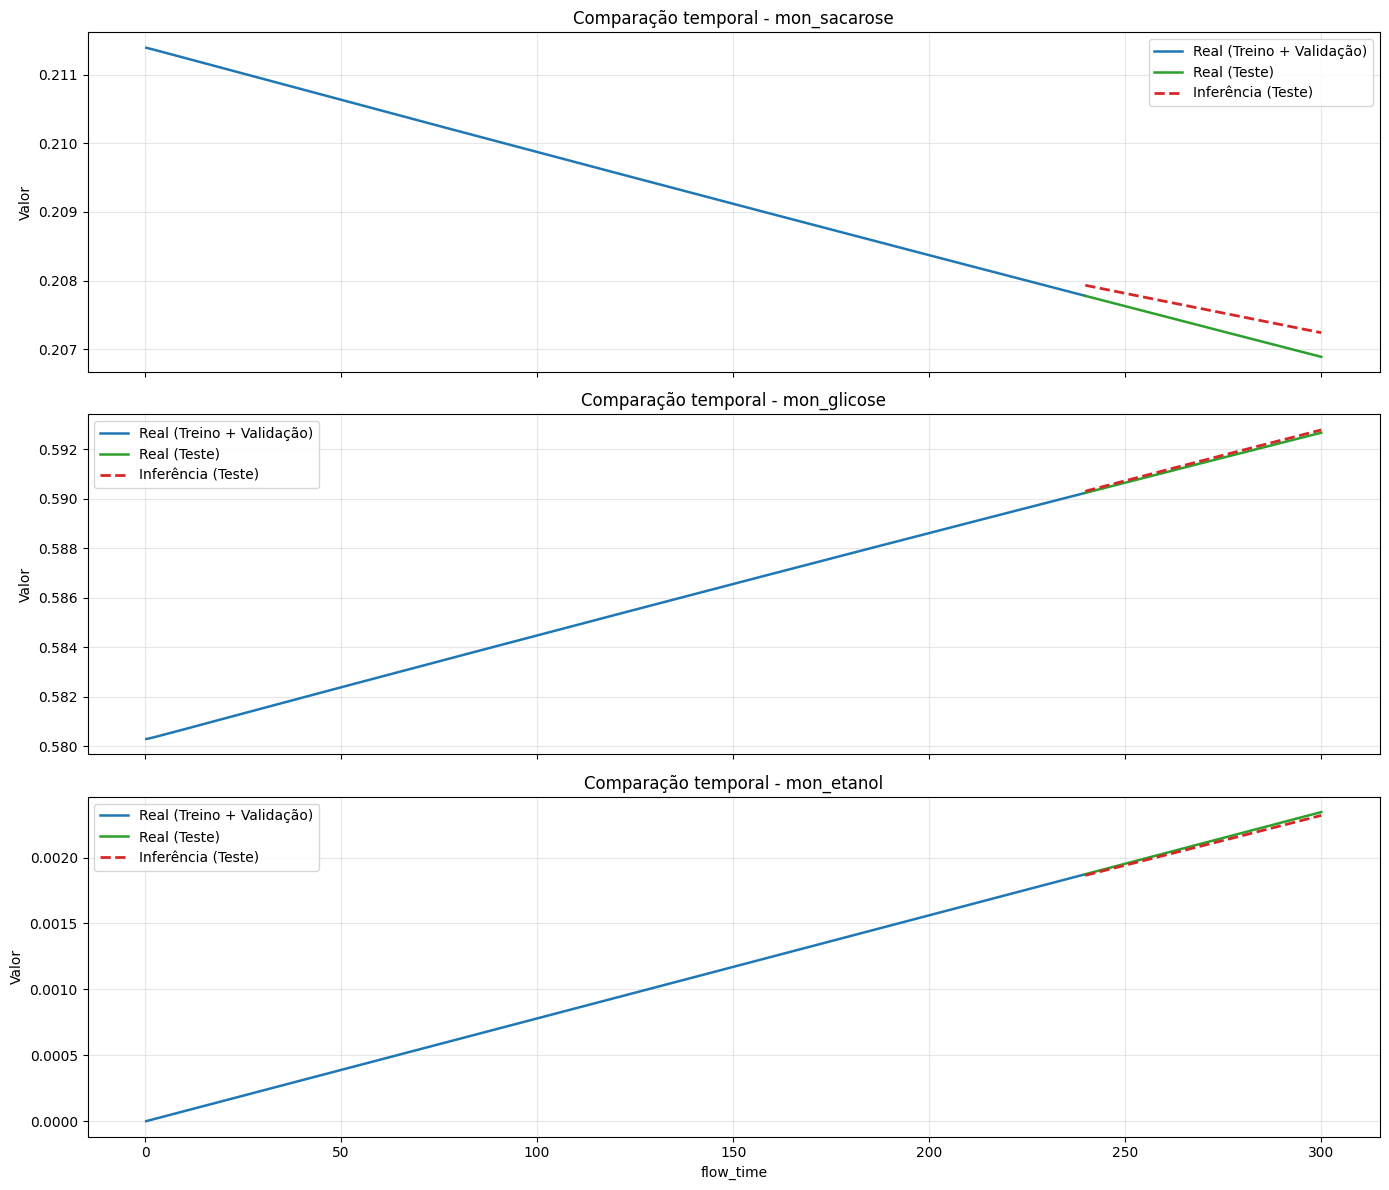

In [25]:
import matplotlib.pyplot as plt

# Reconstrói os índices temporais alinhados com as janelas usadas no modelo
n_samples = len(X_hist)
n_trainval = len(X_train) + len(X_val)
n_test = len(X_test)

sample_idx = np.arange(WINDOW_SIZE, WINDOW_SIZE + n_samples)
trainval_sample_idx = sample_idx[:n_trainval]
test_sample_idx = sample_idx[n_trainval:]

trainval_time = df["flow_time"].iloc[trainval_sample_idx].to_numpy()
test_time = df["flow_time"].iloc[test_sample_idx].to_numpy()

# Valores reais em escala original
y_trainval_real = inverse_state(state_scaler, y[:n_trainval])
y_test_real = y_test_rescaled
y_pred_test = predictions_rescaled

variables = ["mon_sacarose", "mon_glicose", "mon_etanol"]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, var_name in enumerate(variables):
    axes[i].plot(
        trainval_time,
        y_trainval_real[:, i],
        label="Real (Treino + Validação)",
        color="tab:blue",
        linewidth=1.8,
    )
    axes[i].plot(
        test_time,
        y_test_real[:, i],
        label="Real (Teste)",
        color="tab:green",
        linewidth=1.8,
    )
    axes[i].plot(
        test_time,
        y_pred_test[:, i],
        label="Inferência (Teste)",
        color="tab:red",
        linestyle="--",
        linewidth=2.0,
    )

    axes[i].set_title(f"Comparação temporal - {var_name}")
    axes[i].set_ylabel("Valor")
    axes[i].grid(alpha=0.3)
    axes[i].legend(loc="best")

axes[-1].set_xlabel("flow_time")
plt.tight_layout()
plt.show()

# Inferencia

In [26]:
def load_checkpoint(checkpoint_path: Path, device):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    return checkpoint

In [27]:
def build_last_history(df, state_scaler, flow_scaler, window_size):
    state_values = df[["mon_sacarose", "mon_glicose", "mon_etanol"]].values
    flow_values = df[["flow_time"]].values

    state_scaled = state_scaler.transform(state_values)
    flow_scaled = flow_scaler.transform(flow_values)

    X_hist, _, _ = create_samples(state_scaled, flow_scaled, window_size)
    return X_hist[-1]

In [28]:
def forecast_future_steps(
    model,
    last_history_features,
    future_flow_scaled,
    state_scaler,
    flow_scaler,
    device,
):
    model.eval()
    history = last_history_features.copy()
    forecasts = []

    # Aceita entrada como array 1D (n,) ou 2D (n, 1).
    future_flow_scaled = np.asarray(future_flow_scaled).reshape(-1)

    with torch.no_grad():
        for next_flow_scaled in future_flow_scaled:
            hist_tensor = torch.FloatTensor(history[None, :, :]).to(device)
            flow_tensor = torch.FloatTensor([[next_flow_scaled]]).to(device)

            predicted_state_scaled = model(hist_tensor, flow_tensor).cpu().numpy()
            predicted_state = inverse_state(state_scaler, predicted_state_scaled)
            forecasts.append(predicted_state[0])

            # Próxima linha do histórico: estado previsto + flow_time futuro informado.
            next_row = np.array(
                [
                    predicted_state_scaled[0, 0],
                    predicted_state_scaled[0, 1],
                    predicted_state_scaled[0, 2],
                    next_flow_scaled,
                ]
            )
            history = np.vstack([history[1:], next_row])

    return np.array(forecasts)

In [29]:
checkpoint = Path(OUTPUT_DIR / "modelo_temporal_3.pth")
checkpoint = load_checkpoint(checkpoint, device)

In [30]:
state_scaler = checkpoint["state_scaler"]
flow_scaler = checkpoint["flow_scaler"]
window_size = checkpoint.get("window_size", WINDOW_SIZE)

In [31]:
dataset = CSV_PATH
df = load_data(dataset)

In [32]:
last_observed_time = float(df["flow_time"].iloc[-1])
time_step = 0.1  # Defina o passo temporal desejado
final_time = 10800
if time_step <= 0:
    raise ValueError("O passo temporal deve ser positivo.")
if final_time <= last_observed_time:
    raise ValueError("O tempo final deve ser maior que o ultimo flow_time observado.")

In [33]:
print(f"Ultimo flow_time observado: {last_observed_time:.4f} segundos")
delta_t_total = final_time - last_observed_time
print(f"Delta_t total para previsao: {delta_t_total:.4f} segundos")
num_inferences_float = delta_t_total / time_step
print(f"Quantidade de inferencias calculada (float): {num_inferences_float:.4f}")   
    

Ultimo flow_time observado: 299.9848 segundos
Delta_t total para previsao: 10500.0152 segundos
Quantidade de inferencias calculada (float): 105000.1523


In [34]:
# Fixed: Use floor instead of round to avoid exceeding final_time
num_inferences = int(math.floor(num_inferences_float))
print(f"Quantidade de inferencias calculada (int): {num_inferences}")

Quantidade de inferencias calculada (int): 105000


In [35]:
# Adjust final time to be multiple of time_step
final_time = last_observed_time + num_inferences * time_step
print(f"Tempo final ajustado para ser multiplo do passo: {final_time:.4f} segundos")

if num_inferences <= 0:
    raise ValueError("A configuracao informada resulta em zero inferencias.")   

Tempo final ajustado para ser multiplo do passo: 10799.9848 segundos


In [36]:
#Criando future flow times para as inferencias futuras usando o passo temporal definido
future_deltas_raw = np.full((num_inferences, 1), time_step, dtype=float)
future_flow_times = last_observed_time + np.cumsum(future_deltas_raw.flatten())
print(f"Future flow times para inferencias futuras: {future_flow_times}")
# Da para fazer a mesma coisa com numpy.arange, mas assim fica mais claro que estamos 
# usando o passo temporal definido
future_flow_times = np.arange(last_observed_time + time_step, last_observed_time + (num_inferences + 1) * time_step, step=time_step)
print(f"Future flow times para inferencias futuras: {future_flow_times}")

Future flow times para inferencias futuras: [  300.08476647   300.18476647   300.28476647 ... 10799.78476649
 10799.88476649 10799.98476649]
Future flow times para inferencias futuras: [  300.08476647   300.18476647   300.28476647 ... 10799.78476647
 10799.88476647 10799.98476647]


In [37]:
future_flow_scaled = flow_scaler.transform(future_flow_times.reshape(-1, 1)).reshape(-1)
print(f"Future flow times escalados para inferencias futuras: {future_flow_scaled}")

Future flow times escalados para inferencias futuras: [ 1.00033335  1.0006667   1.00100005 ... 36.00111063 36.00144398
 36.00177734]


In [38]:
last_history = build_last_history(df, state_scaler, flow_scaler, window_size)

In [39]:
# Fixed: Use correct num_layers from checkpoint (2, not 12)
model = TimeConditionedLSTM(
    input_size=checkpoint.get("input_size", 4),
    hidden_size=checkpoint.get("hidden_size", 64),
    num_layers=checkpoint.get("num_layers", 2),  # Fixed: Use 2 as default, not 12
    output_size=3,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

TimeConditionedLSTM(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.1)
  (time_encoder): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [40]:
predictions = forecast_future_steps(
    model,
    last_history,
    future_flow_scaled,
    state_scaler,
    flow_scaler,
    device,
)

In [41]:
results_df = pd.DataFrame(
    {
        "flow_time": future_flow_times,
        "pred_mon_sacarose": predictions[:, 0],
        "pred_mon_glicose": predictions[:, 1],
        "pred_mon_etanol": predictions[:, 2],
    }
)

In [42]:
print(f"Quantidade de inferencias: {num_inferences}")
print(results_df.head(10))

Quantidade de inferencias: 105000
    flow_time  pred_mon_sacarose  pred_mon_glicose  pred_mon_etanol
0  300.084766           0.207239          0.592785         0.002319
1  300.184766           0.207238          0.592789         0.002320
2  300.284766           0.207237          0.592793         0.002321
3  300.384766           0.207236          0.592798         0.002322
4  300.484766           0.207235          0.592802         0.002322
5  300.584766           0.207234          0.592806         0.002323
6  300.684766           0.207232          0.592810         0.002324
7  300.784766           0.207231          0.592814         0.002325
8  300.884766           0.207230          0.592818         0.002326
9  300.984766           0.207229          0.592822         0.002326


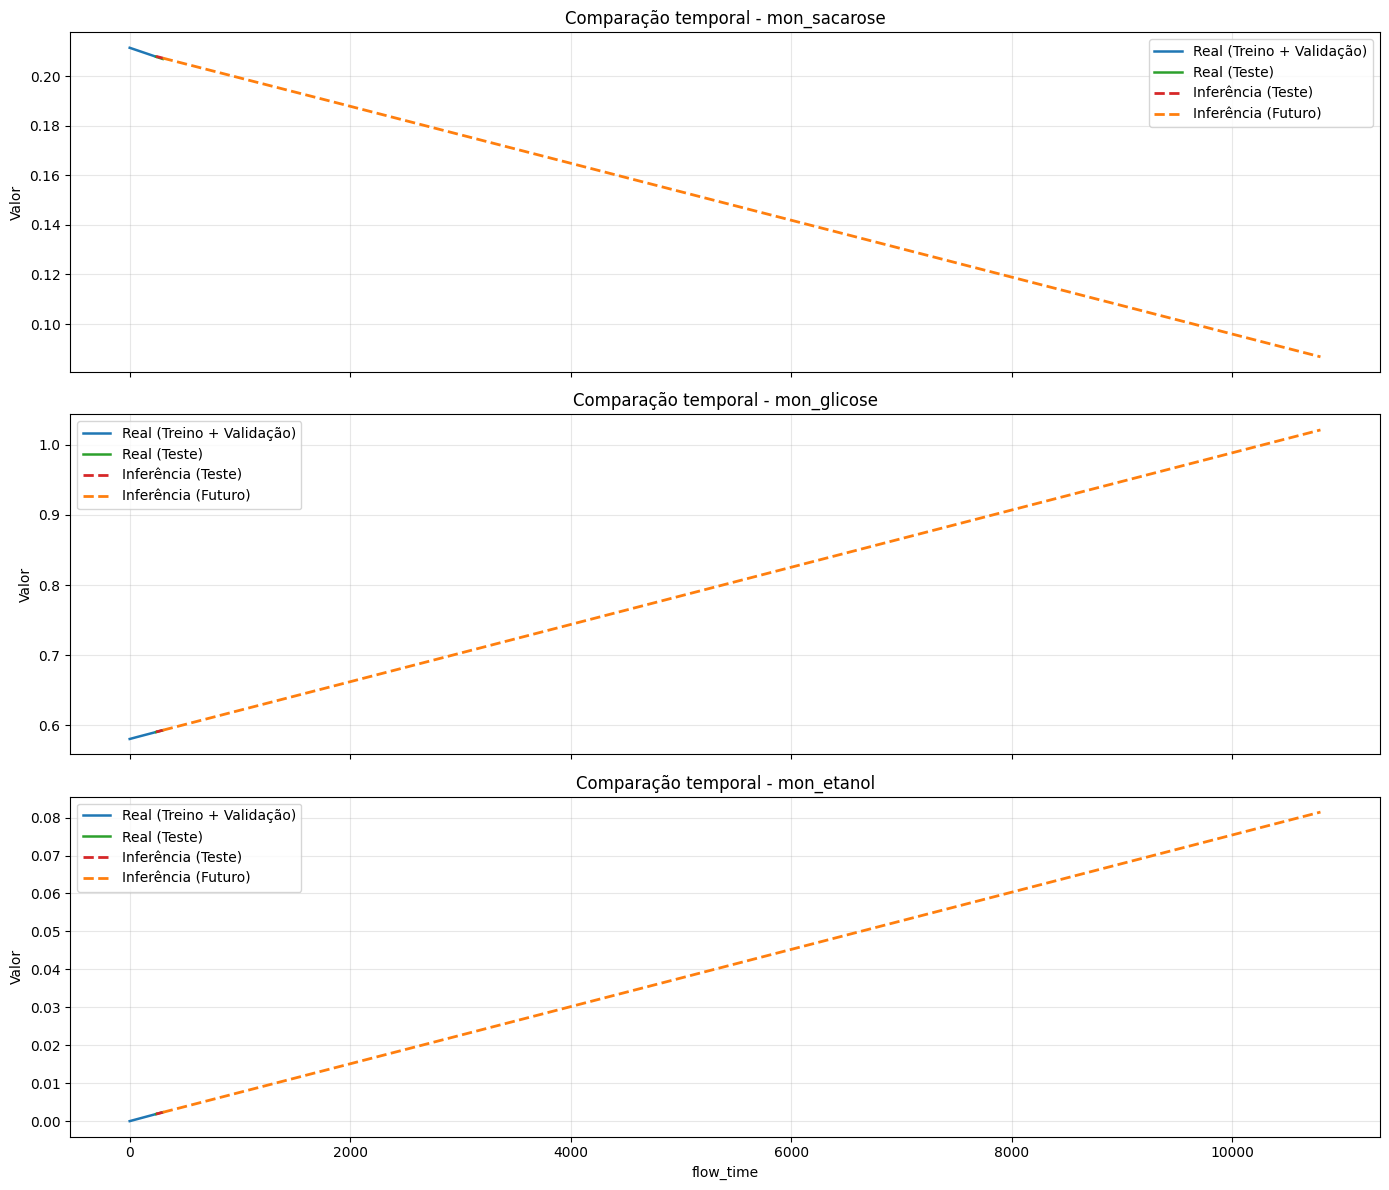

In [43]:
# Criar um plot como o anterior adicionando as novas inferências futuras, mantendo o histórico de 
# treino e teste, e adicionando as inferências futuras.
# Reconstrói os índices temporais alinhados com as janelas usadas no modelo
n_samples = len(X_hist)
n_trainval = len(X_train) + len(X_val)
n_test = len(X_test)

sample_idx = np.arange(WINDOW_SIZE, WINDOW_SIZE + n_samples)
trainval_sample_idx = sample_idx[:n_trainval]
test_sample_idx = sample_idx[n_trainval:]

trainval_time = df["flow_time"].iloc[trainval_sample_idx].to_numpy()
test_time = df["flow_time"].iloc[test_sample_idx].to_numpy()

# Valores reais em escala original
y_trainval_real = inverse_state(state_scaler, y[:n_trainval])
y_test_real = y_test_rescaled
y_pred_test = predictions_rescaled

variables = ["mon_sacarose", "mon_glicose", "mon_etanol"]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, var_name in enumerate(variables):
    axes[i].plot(
        trainval_time,
        y_trainval_real[:, i],
        label="Real (Treino + Validação)",
        color="tab:blue",
        linewidth=1.8,
    )
    axes[i].plot(
        test_time,
        y_test_real[:, i],
        label="Real (Teste)",
        color="tab:green",
        linewidth=1.8,
    )
    axes[i].plot(
        test_time,
        y_pred_test[:, i],
        label="Inferência (Teste)",
        color="tab:red",
        linestyle="--",
        linewidth=2.0,
    )

    axes[i].plot(
        future_flow_times,
        predictions[:, i],
        label="Inferência (Futuro)",
        color="tab:orange",
        linestyle="--",
        linewidth=2.0,
    )

    axes[i].set_title(f"Comparação temporal - {var_name}")
    axes[i].set_ylabel("Valor")
    axes[i].grid(alpha=0.3)
    axes[i].legend(loc="best")

axes[-1].set_xlabel("flow_time")
plt.tight_layout()
plt.show()